--- Running Case 1: 1-Soliton ---
Mean difference across entire space-time domain: 4.5691e-16



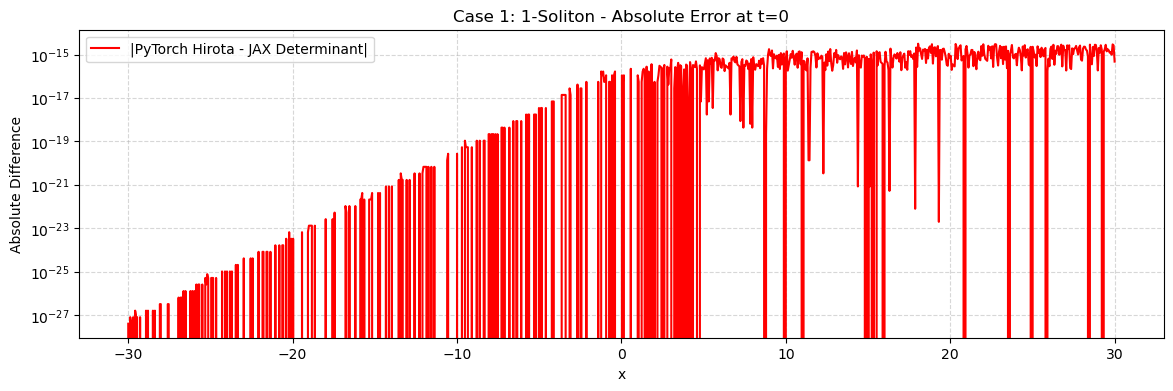

True
--- Running Case 2: 2-Soliton ---
Mean difference across entire space-time domain: 1.3775e-15



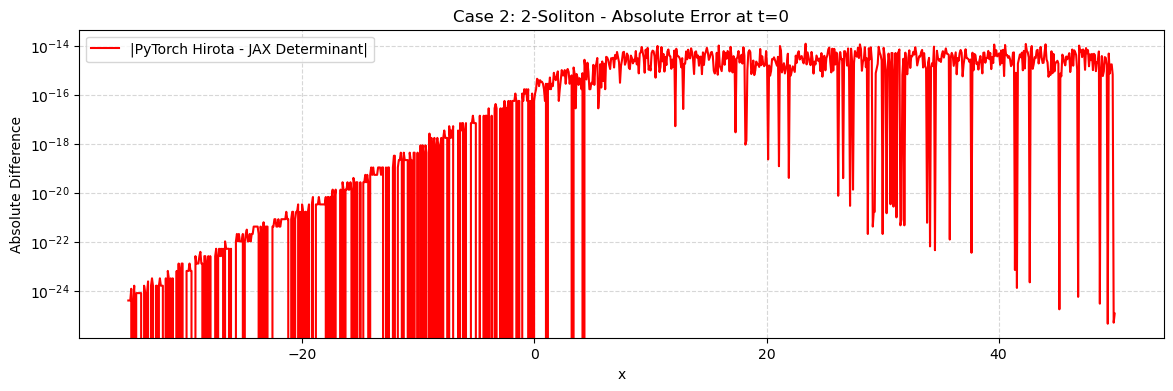

True
--- Running Case 3: 3-Soliton ---
Mean difference across entire space-time domain: 8.0063e-10



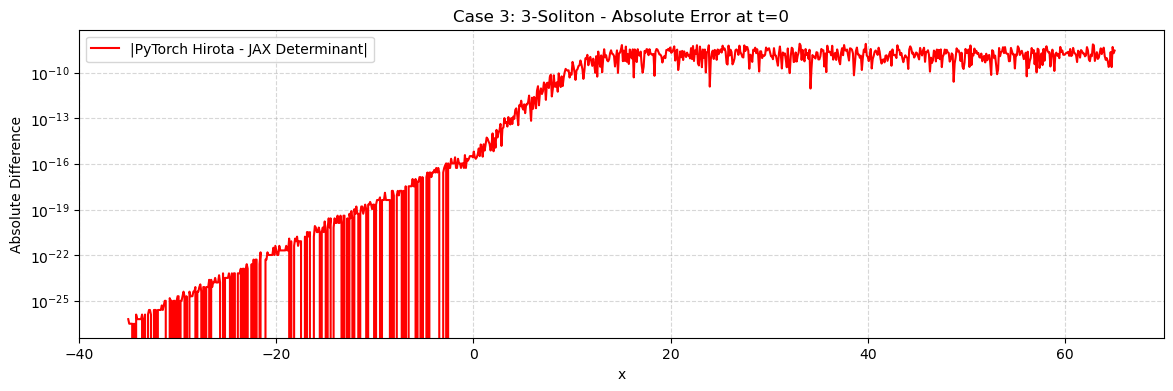

True


In [2]:
import jax
import jax.numpy as jnp
from jaxtyping import Array, Float
from typing import Callable

import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. ENFORCE 64-BIT PRECISION FOR FAIR COMPARISON
jax.config.update("jax_enable_x64", True)

# ==========================================
# JAX IMPLEMENTATION
# ==========================================
def build_n_soliton(k_vec: Array, d_vec: Array) -> tuple[Callable]:
    N = k_vec.size
    k_row = k_vec[None, :]
    k_col = k_vec[:, None]
    C = 2.0 * k_col / (k_row + k_col)
    I = jnp.eye(N)

    def f(x: Float, t: Float) -> Float:
        eta = k_vec * (x - k_vec**2 * t) + d_vec
        S = I + C * jnp.exp(eta)[None, :]
        return jnp.linalg.det(S)
    
    f_x = jax.grad(f, argnums=0)
    f_xx = jax.grad(f_x, argnums=0)

    def u(x: Float, t: Float) -> Float: 
        fv = f(x, t)
        fxv = f_x(x, t)
        fxxv = f_xx(x, t)
        return 2.0 * (fv * fxxv - fxv**2) / (fv**2)

    return u, f, f_x, f_xx

# ==========================================
# PYTORCH IMPLEMENTATION
# ==========================================
def n_soliton(x: torch.Tensor, t: torch.Tensor, 
              k_vec: torch.Tensor, delta_vec: torch.Tensor) -> torch.Tensor:
    x_d = x.to(torch.float64)
    t_d = t.to(torch.float64)
    k = torch.as_tensor(k_vec, dtype=torch.float64, device=x.device)
    d = torch.as_tensor(delta_vec, dtype=torch.float64, device=x.device)
    n = k.numel()

    if n == 1:
        eta1 = k * (x_d - k**2 * t_d) + d
        f    = 1.0 + torch.exp(eta1)
        fx   = k * torch.exp(eta1)
        fxx  = k**2 * torch.exp(eta1)
        u = 2.0 * (f * fxx - fx**2) / f**2
        return u.to(x.dtype)
    
    elif n == 2:
        k1, k2 = k
        d1, d2 = d
        eta1 = k1 * (x_d - k1**2 * t_d) + d1
        eta2 = k2 * (x_d - k2**2 * t_d) + d2
        A12 = ((k1 - k2) / (k1 + k2))**2
        
        exp1, exp2, exp12 = torch.exp(eta1), torch.exp(eta2), torch.exp(eta1 + eta2)
        f   = 1.0 + exp1 + exp2 + A12 * exp12
        fx  = k1 * exp1 + k2 * exp2 + A12 * (k1 + k2) * exp12
        fxx = k1**2 * exp1 + k2**2 * exp2 + A12 * (k1 + k2)**2 * exp12
        u = 2.0 * (f * fxx - fx**2) / f**2
        return u.to(x.dtype)
    
    elif n == 3:
        k1, k2, k3 = k
        d1, d2, d3 = d
        eta1 = k1 * (x_d - k1**2 * t_d) + d1
        eta2 = k2 * (x_d - k2**2 * t_d) + d2
        eta3 = k3 * (x_d - k3**2 * t_d) + d3

        A12 = ((k1 - k2) / (k1 + k2))**2
        A13 = ((k1 - k3) / (k1 + k3))**2
        A23 = ((k2 - k3) / (k2 + k3))**2

        exp1, exp2, exp3 = torch.exp(eta1), torch.exp(eta2), torch.exp(eta3)
        exp12, exp13, exp23 = torch.exp(eta1 + eta2), torch.exp(eta1 + eta3), torch.exp(eta2 + eta3)
        exp123 = torch.exp(eta1 + eta2 + eta3)

        f = 1.0 + exp1 + exp2 + exp3 + A12 * exp12 + A13 * exp13 + A23 * exp23 + A12 * A13 * A23 * exp123
        fx = (k1 * exp1 + k2 * exp2 + k3 * exp3 + A12 * (k1 + k2) * exp12 + 
              A13 * (k1 + k3) * exp13 + A23 * (k2 + k3) * exp23 + 
              A12 * A13 * A23 * (k1 + k2 + k3) * exp123)
        fxx = (k1**2 * exp1 + k2**2 * exp2 + k3**2 * exp3 + A12 * (k1 + k2)**2 * exp12 + 
               A13 * (k1 + k3)**2 * exp13 + A23 * (k2 + k3)**2 * exp23 + 
               A12 * A13 * A23 * (k1 + k2 + k3)**2 * exp123)
        u = 2.0 * (f * fxx - fx**2) / f**2
        return u.to(x.dtype)
    else:
        raise ValueError("n_soliton implemented only for N = 1, 2 or 3 solitons")

# ==========================================
# TEST CASES & EVALUATION
# ==========================================
cases = [
    {
        "name": "Case 1: 1-Soliton",
        "x_lims": [-30, 30], "t_lims": [-15, 15],
        "k": [0.9], "phi": [0.0]
    },
    {
        "name": "Case 2: 2-Soliton",
        "x_lims": [-35, 50], "t_lims": [-20, 35],
        "k": [np.sqrt(1.0), np.sqrt(0.3)], "phi": [0.0, 0.0]
    },
    {
        "name": "Case 3: 3-Soliton",
        "x_lims": [-35, 65], "t_lims": [-25, 50],
        "k": [np.sqrt(1.0), np.sqrt(0.8), np.sqrt(0.5)], "phi": [0.0, 0.0, 0.0]
    }
]

device = "cpu" # Defaulting to CPU for cross-framework memory safety in testing

for i, case in enumerate(cases):
    print(f"--- Running {case['name']} ---")
    
    # Generate a dense 2D space-time grid for rigorous Mean Difference testing
    x_grid = np.linspace(case["x_lims"][0], case["x_lims"][1], 500)
    t_grid = np.linspace(case["t_lims"][0], case["t_lims"][1], 500)
    X, T = np.meshgrid(x_grid, t_grid)
    x_flat, t_flat = X.flatten(), T.flatten()
    
    # 1. Compute via PyTorch
    u_pt = n_soliton(
        x=torch.tensor(x_flat, device=device, dtype=torch.float64),
        t=torch.tensor(t_flat, device=device, dtype=torch.float64),
        k_vec=torch.tensor(case["k"], device=device, dtype=torch.float64),
        delta_vec=torch.tensor(case["phi"], device=device, dtype=torch.float64)
    ).cpu().numpy()

    # 2. Compute via JAX
    u_fn = build_n_soliton(jnp.array(case["k"], dtype=jnp.float64), 
                           jnp.array(case["phi"], dtype=jnp.float64))[0]
    # vmap the JAX function to handle the flattened arrays
    u_jax = jax.vmap(u_fn)(jnp.array(x_flat, dtype=jnp.float64), 
                           jnp.array(t_flat, dtype=jnp.float64))
    u_jax = np.array(u_jax)

    # Calculate overall grid difference
    diff = np.abs(u_pt - u_jax)
    print(f"Mean difference across entire space-time domain: {np.mean(diff):.4e}\n")

    # 3. Generate 1D slice for plotting (at t = 0)
    x_plot = np.linspace(case["x_lims"][0], case["x_lims"][1], 1000)
    t_plot = np.zeros_like(x_plot)
    
    u_pt_plot = n_soliton(
        torch.tensor(x_plot, dtype=torch.float64), torch.tensor(t_plot, dtype=torch.float64),
        torch.tensor(case["k"], dtype=torch.float64), torch.tensor(case["phi"], dtype=torch.float64)
    ).numpy()
    
    u_jax_plot = jax.vmap(u_fn)(jnp.array(x_plot, dtype=jnp.float64), jnp.array(t_plot, dtype=jnp.float64))
    diff_plot = np.abs(u_pt_plot - u_jax_plot)

    # Plotting
    plt.figure(figsize=(14, 4))
    plt.plot(x_plot, diff_plot, label='|PyTorch Hirota - JAX Determinant|', color='red', linewidth=1.5)
    plt.yscale('log')
    plt.title(f"{case['name']} - Absolute Error at t=0")
    plt.xlabel('x')
    plt.ylabel('Absolute Difference')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()
    print(np.allclose(u_pt_plot, u_jax_plot))